In [1]:
# Cell 1: Setup & Load Data
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the arrays we saved in Phase 2
print("Loading data...")
X_train = np.load('data/processed/X_train.npy')
X_test = np.load('data/processed/X_test.npy')
y_train = np.load('data/processed/y_train.npy')
y_test = np.load('data/processed/y_test.npy')

# Load feature names (so we know which column is which)
feature_names = joblib.load('data/processed/feature_names.pkl')

print(f"✅ Data Loaded.")
print(f"Training Features: {X_train.shape}")
print(f"Testing Features:  {X_test.shape}")

Loading data...
✅ Data Loaded.
Training Features: (2444, 7)
Testing Features:  (612, 7)


In [2]:
# Cell 2: Train the Random Forest Model
print("Training the model... (This might take a moment)")

# Initialize the model
# n_estimators=100 means we are creating 100 decision trees
# random_state=42 ensures consistent results
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model (Fit)
model.fit(X_train, y_train)

print("✅ Model Trained Successfully!")

Training the model... (This might take a moment)
✅ Model Trained Successfully!


In [3]:
# Cell 3: Evaluation
# Make predictions on the Test Set (data the model has NEVER seen)
y_pred = model.predict(X_test)

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Model Accuracy: {accuracy:.2%}")
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Safe', 'Fire']))

# Key Metrics to look at:
# Precision: When it predicts "Fire", how often is it right?
# Recall: Out of all ACTUAL fires, how many did it catch?

🎯 Model Accuracy: 89.22%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

        Safe       0.91      0.86      0.89       296
        Fire       0.88      0.92      0.90       316

    accuracy                           0.89       612
   macro avg       0.89      0.89      0.89       612
weighted avg       0.89      0.89      0.89       612



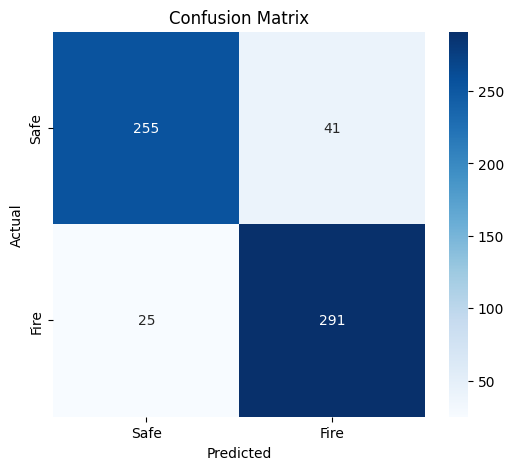

In [4]:
# Cell 4: Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Safe', 'Fire'],
            yticklabels=['Safe', 'Fire'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

C:\Users\vaast\AppData\Local\Temp\ipykernel_17040\2226678081.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')


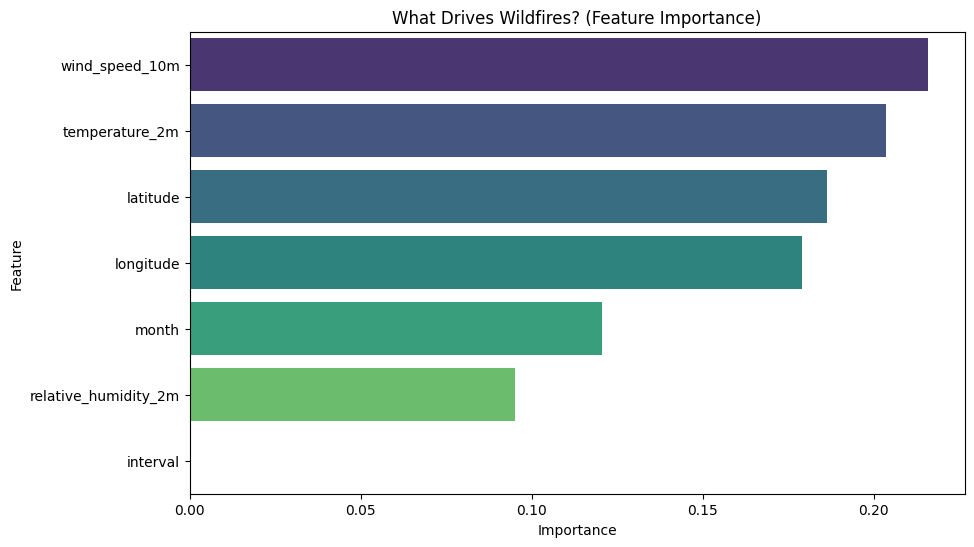

Top 3 Predictors:
          Feature  Importance
5  wind_speed_10m    0.215780
3  temperature_2m    0.203474
0        latitude    0.186267


In [5]:
# Cell 5: Feature Importance
import pandas as pd

# Get importance scores
importances = model.feature_importances_

# Create a DataFrame for plotting
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
plt.title('What Drives Wildfires? (Feature Importance)')
plt.show()

print("Top 3 Predictors:")
print(feature_df.head(3))

In [6]:
# Cell 6: Save the Model
joblib.dump(model, 'data/processed/random_forest_model.pkl')
print("✅ Model saved to 'data/processed/random_forest_model.pkl'")
print("Ready for Phase 4 (Prediction System)!")

✅ Model saved to 'data/processed/random_forest_model.pkl'
Ready for Phase 4 (Prediction System)!


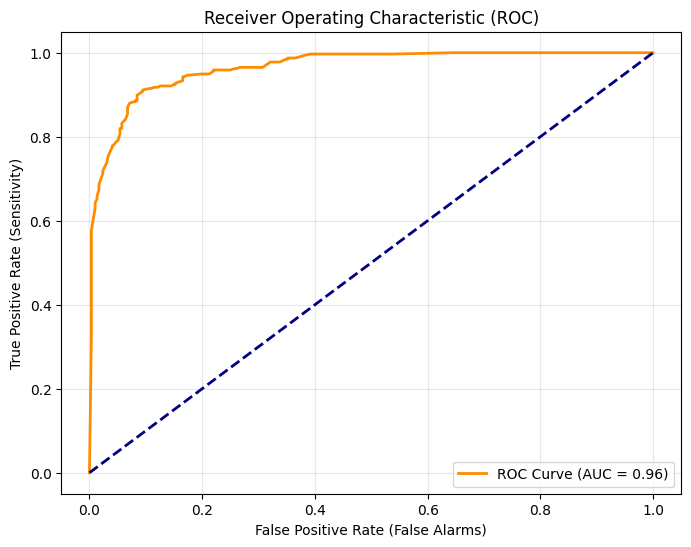

🏆 AUC Score: 0.96
(1.0 = Perfect | 0.9 = Excellent | 0.8 = Good | 0.5 = Guessing)


In [7]:
# Cell 7: ROC Curve & AUC Score (The Professional Standard)
from sklearn.metrics import roc_curve, auc

# 1. Get probability scores (instead of just 0 or 1)
y_probs = model.predict_proba(X_test)[:, 1]

# 2. Calculate ROC metrics
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# 3. Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Random guess line
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"🏆 AUC Score: {roc_auc:.2f}")
print("(1.0 = Perfect | 0.9 = Excellent | 0.8 = Good | 0.5 = Guessing)")

In [8]:
# Cell 8: The "Sanity Check" (Cross Validation)
from sklearn.model_selection import cross_val_score

print("Running 5-Fold Cross Validation (Stress Test)...")
# This splits the data 5 ways and tests 5 times
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

print(f"Test 1: {scores[0]:.2%}")
print(f"Test 2: {scores[1]:.2%}")
print(f"Test 3: {scores[2]:.2%}")
print(f"Test 4: {scores[3]:.2%}")
print(f"Test 5: {scores[4]:.2%}")
print(f"---")
print(f"AVERAGE REAL ACCURACY: {scores.mean():.2%}")

Running 5-Fold Cross Validation (Stress Test)...
Test 1: 89.98%
Test 2: 93.46%
Test 3: 89.37%
Test 4: 90.59%
Test 5: 91.39%
---
AVERAGE REAL ACCURACY: 90.96%
